## Importing libiraries

In [3]:
import requests
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
%matplotlib notebook
%matplotlib inline

In [4]:


BASE = "https://dashboard.elering.ee/api"

def get_nps_prices(start: str, end: str) -> pd.DataFrame:

    r = requests.get(BASE + "/nps/price", params={"start": start, "end": end})
    r.raise_for_status()

    data = r.json()["data"]  # {"ee": [...], "lv": [...], "lt": [...], "fi": [...]}

    dfs = []
    for country, records in data.items():
        df = pd.DataFrame(records)
        df["timestamp"] = pd.to_datetime(df["timestamp"], unit="s", utc=True)
        df = df.set_index("timestamp")
        df = df.rename(columns={"price": country})
        dfs.append(df)

    df_prices = pd.concat(dfs, axis=1).sort_index()
    return df_prices


def get_cross_border_flows(start: str, end: str) -> pd.DataFrame:

    r = requests.get(BASE + "/transmission/cross-border/hourly", params={"start": start, "end": end})
    r.raise_for_status()

    data = r.json()["data"]

    df = pd.DataFrame(data)
    df["timestamp"] = pd.to_datetime(df["timestamp"], unit="s", utc=True)
    df = df.set_index("timestamp").sort_index()

    # Keep only relevant cross-border flows (drop cable-level detail and Russia)
    df = df[["finland", "latvia"]]
    df.columns = [("ee", "fi"), ("ee", "lv")]

    return df




df_prices = get_nps_prices(
    start="2024-12-31T23:00:00.000Z",
    end="2025-12-31T22:59:59.999Z",
)

df_prices.head()



,ee,fi,lv,lt
timestamp,,,,
2024-12-31 23:00:00+00:00,4.85,4.85,4.85,2.97
2025-01-01 00:00:00+00:00,3.95,3.95,3.95,2.30
2025-01-01 01:00:00+00:00,3.80,3.80,3.80,2.28
2025-01-01 02:00:00+00:00,3.46,3.46,3.46,1.80
2025-01-01 03:00:00+00:00,3.44,3.44,3.44,1.50


In [5]:
df_flows = get_cross_border_flows(
    start="2024-12-31T23:00:00.000Z",
    end="2025-12-31T22:59:59.999Z",
)

df_flows.head()

,"(ee, fi)","(ee, lv)"
timestamp,,
2024-12-31 23:00:00+00:00,-139.5833,-76.2500
2025-01-01 00:00:00+00:00,-63.2417,-81.9917
2025-01-01 01:00:00+00:00,19.0917,-86.0250
2025-01-01 02:00:00+00:00,114.6583,-82.7833
2025-01-01 03:00:00+00:00,-265.5417,200.7167


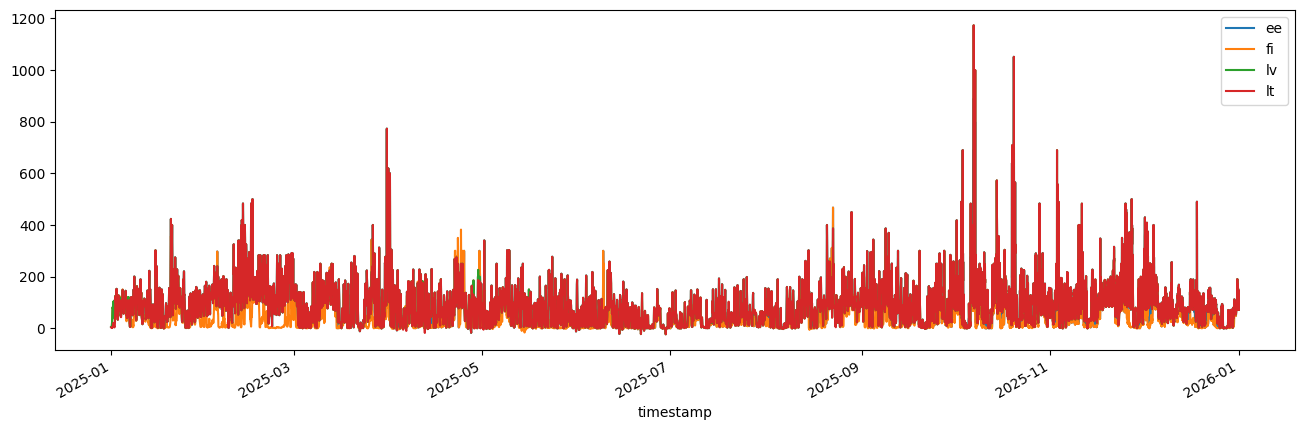

In [22]:
df_prices.plot(figsize=(16, 5));


In [25]:
df_prices.corr()

,ee,fi,lv,lt
ee,1.000000,0.589559,0.919869,0.917392
fi,0.589559,1.000000,0.519624,0.514409
lv,0.919869,0.519624,1.000000,0.998123
lt,0.917392,0.514409,0.998123,1.000000


In [67]:
df_prices.corr().to_dict()




def df_to_edges(df: pd.DataFrame) -> dict:
    weights = {(edge1, edge2): value 
               for edge1, row in df.to_dict().items() 
               for edge2, value in row.items()
               if edge1 != edge2}

    [(k[0], k[1], {'weight': v}) for k, v in weights.items()]


    
    return edges

df_to_edges(df_prices.corr())


[('ee', 'fi', {'weight': 0.5895587748962015}),
 ('ee', 'lv', {'weight': 0.9198690711430757}),
 ('ee', 'lt', {'weight': 0.9173919546950995}),
 ('fi', 'ee', {'weight': 0.5895587748962015}),
 ('fi', 'lv', {'weight': 0.5196240181169166}),
 ('fi', 'lt', {'weight': 0.5144092200957225}),
 ('lv', 'ee', {'weight': 0.9198690711430757}),
 ('lv', 'fi', {'weight': 0.5196240181169166}),
 ('lv', 'lt', {'weight': 0.9981225149153501}),
 ('lt', 'ee', {'weight': 0.9173919546950995}),
 ('lt', 'fi', {'weight': 0.5144092200957225}),
 ('lt', 'lv', {'weight': 0.9981225149153501})]

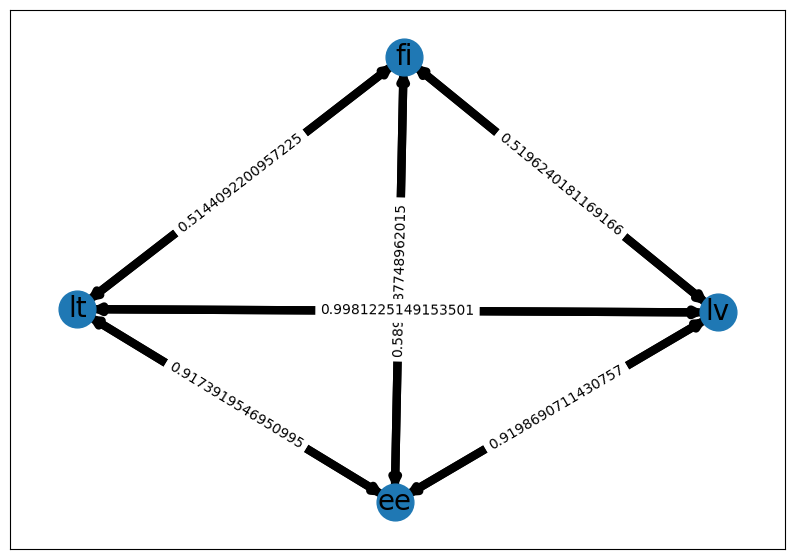

In [70]:
edges = df_to_edges(df_prices.corr())

plt.figure(figsize=(10, 7))

G = nx.DiGraph()
# each edge is a tuple of the form (node1, node2, {'weight': weight})
G.add_edges_from(edges)

pos = nx.spring_layout(G) # positions for all nodes

# nodes
nx.draw_networkx_nodes(G,pos,node_size=700)

# labels
nx.draw_networkx_labels(G,pos,font_size=20,font_family='sans-serif')

# edges
nx.draw_networkx_edges(G,pos,edgelist=edges, width=6)

# weights
labels = nx.get_edge_attributes(G,'weight')
nx.draw_networkx_edge_labels(G,pos,edge_labels=labels);





In [31]:
G